In [ ]:
import pandas as pd
df = pd.read_csv('/content/train.csv')
print("Data head (First 5 rows):")
display(df.head())
print("\nData Shape (Rows, Columns):")
print(df.shape)
print("\nData Information:")
df.info()

Data head (First 5 rows):


,id,date,store_nbr,family,sales,onpromotion
0,0,2013-01-01,1,AUTOMOTIVE,0.0,0
1,1,2013-01-01,1,BABY CARE,0.0,0
2,2,2013-01-01,1,BEAUTY,0.0,0
3,3,2013-01-01,1,BEVERAGES,0.0,0
4,4,2013-01-01,1,BOOKS,0.0,0



Data Shape (Rows, Columns):
(3000888, 6)

Data Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000888 entries, 0 to 3000887
Data columns (total 6 columns):
 #   Column       Dtype  
---  ------       -----  
 0   id           int64  
 1   date         object 
 2   store_nbr    int64  
 3   family       object 
 4   sales        float64
 5   onpromotion  int64  
dtypes: float64(1), int64(3), object(2)
memory usage: 137.4+ MB


In [ ]:

print("Missing values in each column:")
print(df.isnull().sum())
df['sales'] = df['sales'].fillna(0)
df['date'] = pd.to_datetime(df['date'])
print("\nAfter Cleaning:")
print(df.dtypes)
print("\nSample Data:")
display(df.head())

Missing values in each column:
id             0
date           0
store_nbr      0
family         0
sales          0
onpromotion    0
dtype: int64

After Cleaning:
id                      int64
date           datetime64[ns]
store_nbr               int64
family                 object
sales                 float64
onpromotion             int64
dtype: object

Sample Data:


,id,date,store_nbr,family,sales,onpromotion
0,0,2013-01-01,1,AUTOMOTIVE,0.0,0
1,1,2013-01-01,1,BABY CARE,0.0,0
2,2,2013-01-01,1,BEAUTY,0.0,0
3,3,2013-01-01,1,BEVERAGES,0.0,0
4,4,2013-01-01,1,BOOKS,0.0,0


In [ ]:

df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month
df['day'] = df['date'].dt.day
df['day_of_week'] = df['date'].dt.dayofweek
df['is_weekend'] = df['day_of_week'].apply(lambda x: 1 if x >= 5 else 0)
print("new columns added:")
display(df[['date', 'month', 'day_of_week', 'is_weekend']].head())

new columns added:


,date,month,day_of_week,is_weekend
0,2013-01-01,1,1,0
1,2013-01-01,1,1,0
2,2013-01-01,1,1,0
3,2013-01-01,1,1,0
4,2013-01-01,1,1,0


In [ ]:

df['lag_1'] = df['sales'].shift(1)
df['lag_7'] = df['sales'].shift(7)
df['rolling_mean_7'] = df['sales'].shift(1).rolling(window=7).mean()
df.dropna(inplace=True)
print("Lag and Rolling Mean features ready:")
display(df[['date', 'sales', 'lag_1', 'lag_7', 'rolling_mean_7']].head(10))

Lag and Rolling Mean features ready:


,date,sales,lag_1,lag_7,rolling_mean_7
7,2013-01-01,0.0,0.0,0.0,0.0
8,2013-01-01,0.0,0.0,0.0,0.0
9,2013-01-01,0.0,0.0,0.0,0.0
10,2013-01-01,0.0,0.0,0.0,0.0
11,2013-01-01,0.0,0.0,0.0,0.0
12,2013-01-01,0.0,0.0,0.0,0.0
13,2013-01-01,0.0,0.0,0.0,0.0
14,2013-01-01,0.0,0.0,0.0,0.0
15,2013-01-01,0.0,0.0,0.0,0.0
16,2013-01-01,0.0,0.0,0.0,0.0


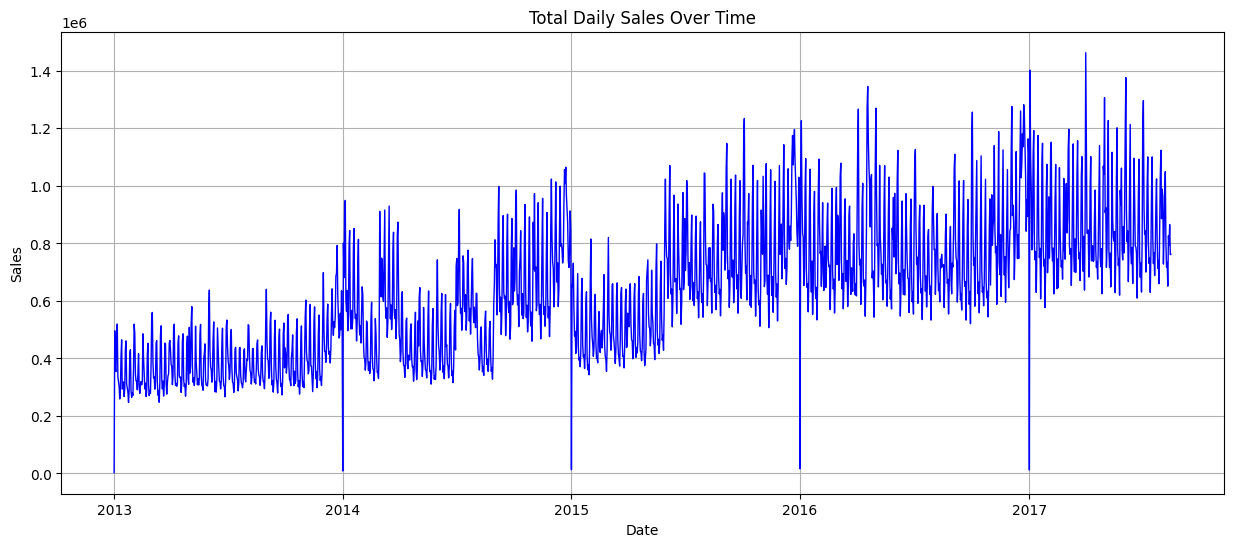

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
daily_sales = df.groupby('date')['sales'].sum().reset_index()
plt.figure(figsize=(15, 6))
plt.plot(daily_sales['date'], daily_sales['sales'], color='blue', linewidth=1)
plt.title('Total Daily Sales Over Time')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.grid(True)
plt.show()

/tmp/ipykernel_7490/1646611669.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='month', y='sales', data=monthly_sales, palette='viridis')


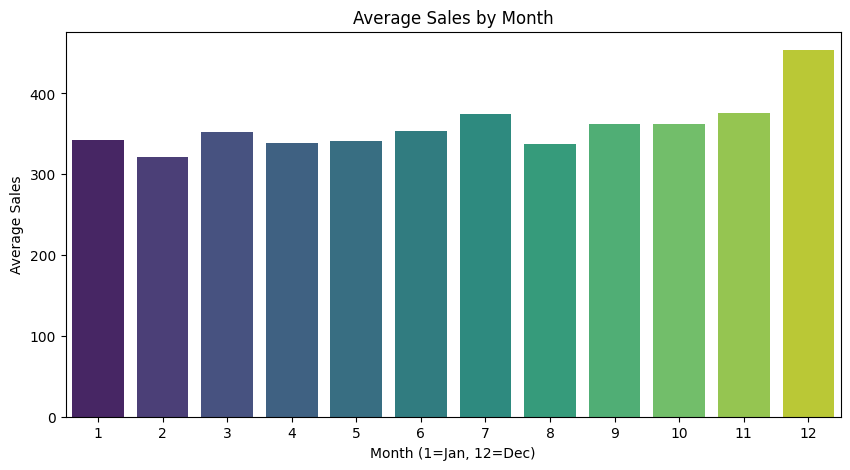

In [ ]:

monthly_sales = df.groupby('month')['sales'].mean().reset_index()
plt.figure(figsize=(10, 5))
sns.barplot(x='month', y='sales', data=monthly_sales, palette='viridis')
plt.title('Average Sales by Month')
plt.xlabel('Month (1=Jan, 12=Dec)')
plt.ylabel('Average Sales')
plt.show()

In [ ]:

X = df.drop(['id', 'date', 'sales'], axis=1)
y = df['sales']
train_size = int(len(df) * 0.8)
X_train, X_test = X.iloc[:train_size], X.iloc[train_size:]
y_train, y_test = y.iloc[:train_size], y.iloc[train_size:]
print(f"Training data size: {X_train.shape}")
print(f"Testing data size: {X_test.shape}")

Training data size: (2400704, 11)
Testing data size: (600177, 11)


In [ ]:
X = df.drop(['id', 'date', 'sales'], axis=1)
y = df['sales']
train_size = int(len(df) * 0.8)
X_train, X_test = X.iloc[:train_size], X.iloc[train_size:]
y_train, y_test = y.iloc[:train_size], y.iloc[train_size:]

In [ ]:
from xgboost import XGBRegressor

X_train_encoded = pd.get_dummies(X_train, columns=['family'], drop_first=True)
X_test_encoded = pd.get_dummies(X_test, columns=['family'], drop_first=True)

model = XGBRegressor(n_estimators=500, learning_rate=0.05, max_depth=5)
print("Model training started")
model.fit(X_train_encoded, y_train)
print("Training Complete!")

Model training started
Training Complete!


In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np
y_pred = model.predict(X_test_encoded)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
print(f"Model RMSE (Error): {rmse:.2f}")
print(f"Model MAE (Average Error): {mae:.2f}")
results = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred})
display(results.head(10))

Model RMSE (Error): 364.78
Model MAE (Average Error): 114.02


,Actual,Predicted
2400711,4.000,1.321483
2400712,85.689,148.281097
2400713,62.000,29.164427
2400714,422.532,916.380615
2400715,0.000,2.677903
2400716,6.000,2.396467
2400717,6.000,15.000002
2400718,1.000,-0.063828
2400719,5.000,11.488559
2400720,2732.000,2954.031006


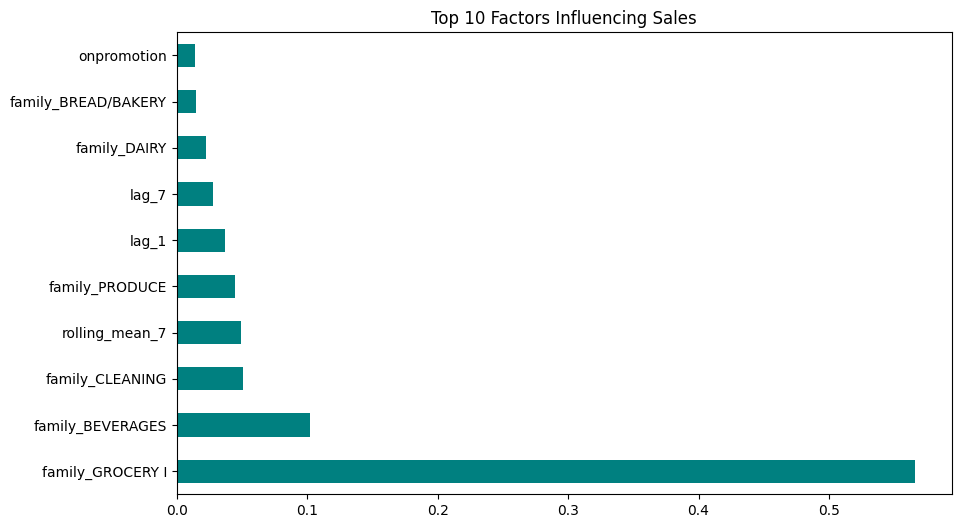

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

plt.figure(figsize=(10, 6))
feat_importances = pd.Series(model.feature_importances_, index=X_train_encoded.columns)
feat_importances.nlargest(10).plot(kind='barh', color='teal')
plt.title('Top 10 Factors Influencing Sales')
plt.show()

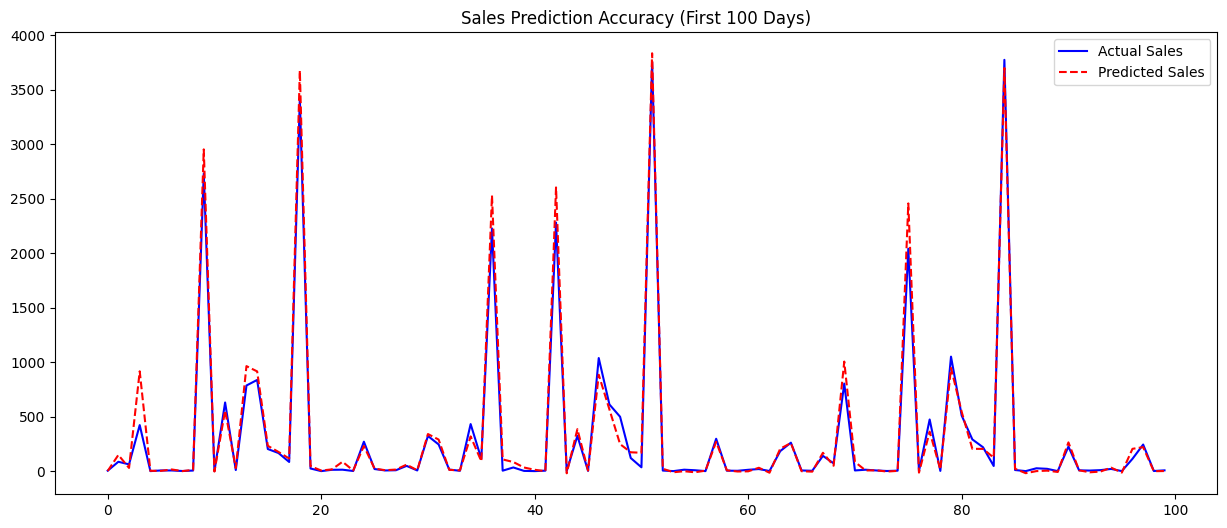

In [ ]:
plt.figure(figsize=(15, 6))
plt.plot(y_test.values[:100], label='Actual Sales', color='blue')
plt.plot(y_pred[:100], label='Predicted Sales', color='red', linestyle='--')
plt.title('Sales Prediction Accuracy (First 100 Days)')
plt.legend()
plt.show()

In [34]:
# Install Prophet library
!pip install prophet

In [44]:
from prophet import Prophet
prophet_train_df = train_ts.reset_index().rename(columns={'date': 'ds', 'sales': 'y'})
print("Prophet training data prepared:")
display(prophet_train_df.head())

Prophet training data prepared:


,ds,y
0,2013-01-01,2511.618999
1,2013-01-02,496092.417944
2,2013-01-03,361461.231124
3,2013-01-04,354459.677093
4,2013-01-05,477350.121229


In [45]:

prophet_model = Prophet(
    seasonality_mode='multiplicative',
    weekly_seasonality=True,
    daily_seasonality=False,
    yearly_seasonality=False
)

print("Prophet model training started...")
prophet_model.fit(prophet_train_df)
print("Prophet model training complete!")

Prophet model training started...
Prophet model training complete!


In [46]:

future = pd.DataFrame({'ds': test_ts.index})
prophet_forecast = prophet_model.predict(future)
prophet_predictions = prophet_forecast.set_index('ds')['yhat']
print("Prophet Predictions:")
display(prophet_predictions.head())

Prophet Predictions:


,yhat
ds,
2016-09-12,735956.154441
2016-09-13,682352.084525
2016-09-14,705189.760498
2016-09-15,599779.561875
2016-09-16,678264.614251


### Evaluating Prophet Model Performance

In [41]:

prophet_rmse = np.sqrt(mean_squared_error(test_ts, prophet_predictions))
prophet_mae = mean_absolute_error(test_ts, prophet_predictions)
print(f"Prophet Model RMSE: {prophet_rmse:.2f}")
print(f"Prophet Model MAE: {prophet_mae:.2f}")
prophet_model_name = 'Prophet (Time Series)'
prophet_rmse_val = prophet_rmse
prophet_mae_val = prophet_mae
comparison_final = comparison_final[comparison_final['Model'] != 'SARIMA (Time Series) - Not Computed']
prophet_comparison_row = pd.DataFrame([{'Model': prophet_model_name, 'RMSE': prophet_rmse_val, 'MAE': prophet_mae_val}])
comparison_final = pd.concat([comparison_final, prophet_comparison_row], ignore_index=True)

print("\nUpdated Model Comparison:")
display(comparison_final)

Prophet Model RMSE: 177944.26
Prophet Model MAE: 136023.41

Updated Model Comparison:


,Model,RMSE,MAE
0,XGBoost (Regression),364.784950,114.017427
1,Prophet (Time Series),177944.262718,136023.414822


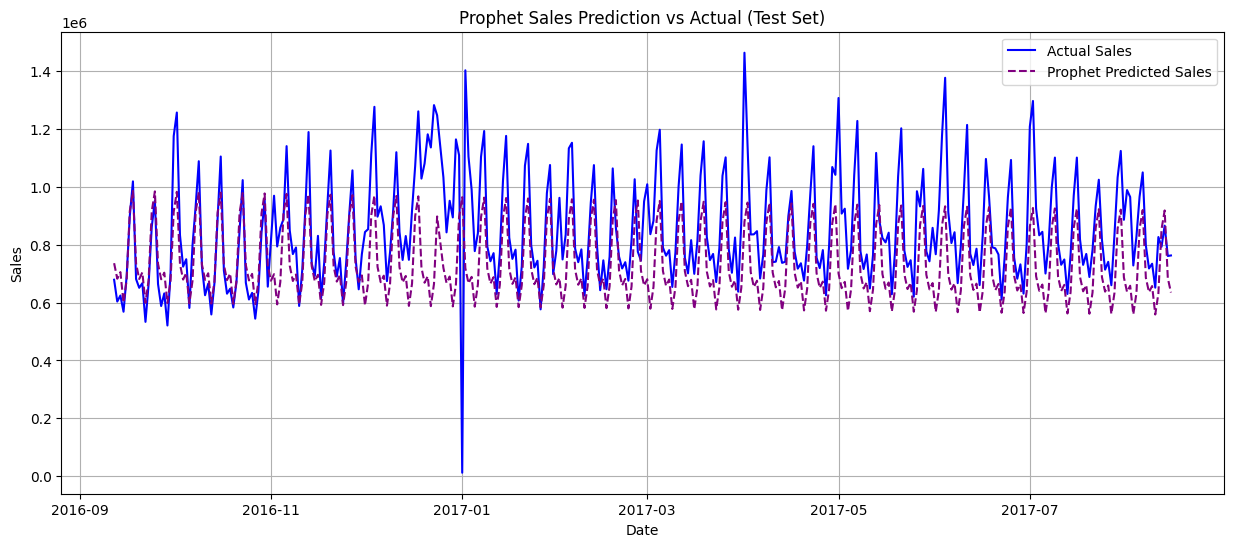

In [42]:

plt.figure(figsize=(15, 6))
plt.plot(test_ts.index, test_ts, label='Actual Sales', color='blue')
plt.plot(prophet_predictions.index, prophet_predictions, label='Prophet Predicted Sales', color='purple', linestyle='--')
plt.title('Prophet Sales Prediction vs Actual (Test Set)')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.legend()
plt.grid(True)
plt.show()

In [47]:
import joblib
joblib.dump(model, 'model.pkl')

['model.pkl']